In [2]:
import pandas as pd
# Phase 1: Data Loading and Exploratory Data Analysis (EDA)

data_sets = pd.read_csv("student_scores_realistic_500.csv")

data_sets.head()


,Study_Hours,Attendance_Percent,Sleep_Hours,Practice_Tests,Score
0,6.57,77,5.6,2,61.6
1,7.50,94,4.9,6,80.1
2,0.80,74,6.8,0,12.5
3,5.83,94,6.4,7,66.2
4,6.10,60,7.9,2,70.0


In [3]:
data_sets.info

<bound method DataFrame.info of      Study_Hours  Attendance_Percent  Sleep_Hours  Practice_Tests  Score
0           6.57                  77          5.6               2   61.6
1           7.50                  94          4.9               6   80.1
2           0.80                  74          6.8               0   12.5
3           5.83                  94          6.4               7   66.2
4           6.10                  60          7.9               2   70.0
..           ...                 ...          ...             ...    ...
495         3.98                  67          5.7               7   41.8
496         5.51                  98          6.2               6   62.2
497         6.08                  89          7.3               4   62.5
498         9.23                  68          5.9               3   93.7
499         3.40                  69          6.8               6   36.5

[500 rows x 5 columns]>

In [4]:
data_sets.describe

<bound method NDFrame.describe of      Study_Hours  Attendance_Percent  Sleep_Hours  Practice_Tests  Score
0           6.57                  77          5.6               2   61.6
1           7.50                  94          4.9               6   80.1
2           0.80                  74          6.8               0   12.5
3           5.83                  94          6.4               7   66.2
4           6.10                  60          7.9               2   70.0
..           ...                 ...          ...             ...    ...
495         3.98                  67          5.7               7   41.8
496         5.51                  98          6.2               6   62.2
497         6.08                  89          7.3               4   62.5
498         9.23                  68          5.9               3   93.7
499         3.40                  69          6.8               6   36.5

[500 rows x 5 columns]>

In [5]:
data_sets.isnull().sum()

Study_Hours           0
Attendance_Percent    0
Sleep_Hours           0
Practice_Tests        0
Score                 0
dtype: int64

In [6]:
data_sets.duplicated().sum()

np.int64(0)

In [7]:
import matplotlib.pyplot as plt

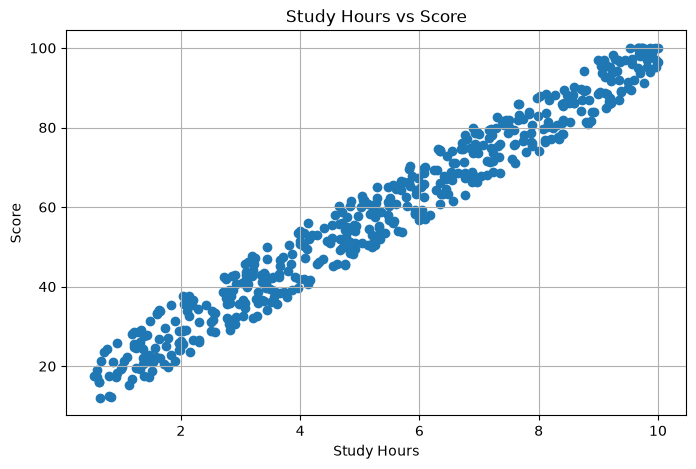

In [8]:
plt.figure(figsize=(8,5))
plt.scatter(data_sets["Study_Hours"], data_sets["Score"])
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.title("Study Hours vs Score")
plt.grid(True)
plt.show()

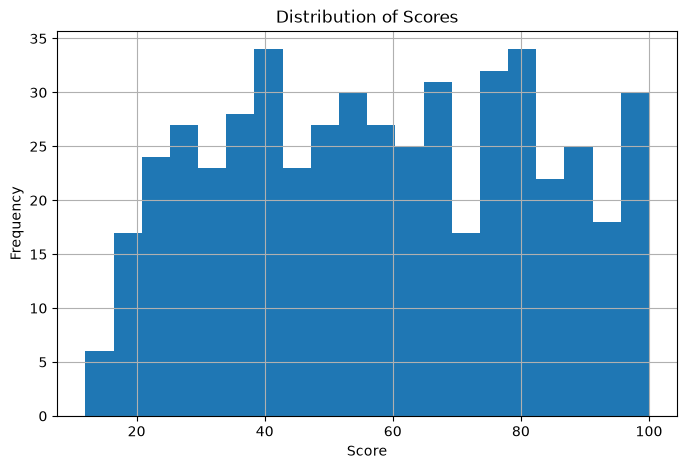

In [9]:
plt.figure(figsize=(8,5))
plt.hist(data_sets["Score"], bins=20)
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.title("Distribution of Scores")
plt.grid(True)
plt.show()

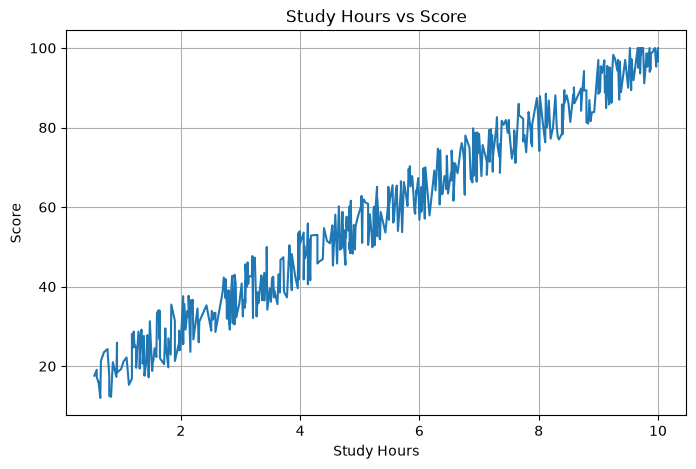

In [10]:
data_sorted = data_sets.sort_values("Study_Hours")

plt.figure(figsize=(8,5))
plt.plot(data_sorted["Study_Hours"], data_sorted["Score"])
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.title("Study Hours vs Score")
plt.grid(True)
plt.show()

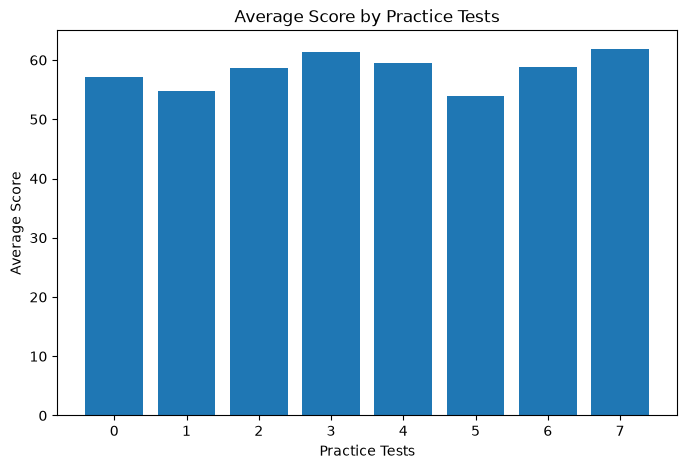

In [11]:
avg = data_sets.groupby("Practice_Tests")["Score"].mean()

plt.figure(figsize=(8,5))
plt.bar(avg.index, avg.values)
plt.xlabel("Practice Tests")
plt.ylabel("Average Score")
plt.title("Average Score by Practice Tests")
plt.show()

In [12]:
print(data_sets.corr(numeric_only=True))

                    Study_Hours  Attendance_Percent  Sleep_Hours  \
Study_Hours            1.000000            0.017833    -0.019495   
Attendance_Percent     0.017833            1.000000    -0.048030   
Sleep_Hours           -0.019495           -0.048030     1.000000   
Practice_Tests         0.034171           -0.076887    -0.045209   
Score                  0.982436            0.017794    -0.018027   

                    Practice_Tests     Score  
Study_Hours               0.034171  0.982436  
Attendance_Percent       -0.076887  0.017794  
Sleep_Hours              -0.045209 -0.018027  
Practice_Tests            1.000000  0.043320  
Score                     0.043320  1.000000  


In [13]:
# Model Traning
X = data_sets[['Study_Hours']]
y = data_sets['Score']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(400, 1)
(100, 1)
(400,)
(100,)


In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[8.75]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Study_Hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,11.44
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [18]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[31.64891241 45.03113767 20.19092869 41.96984431 27.10070513 79.14269226
 91.30040018 56.40165587 89.02629654 30.68679164]


In [20]:
from sklearn.metrics import mean_absolute_error , mean_squared_error, r2_score

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("R2 Score :", r2_score(y_test, y_pred))

MAE : 4.142656124793584
MSE : 22.979888067976944
R2 Score : 0.9559325786186676


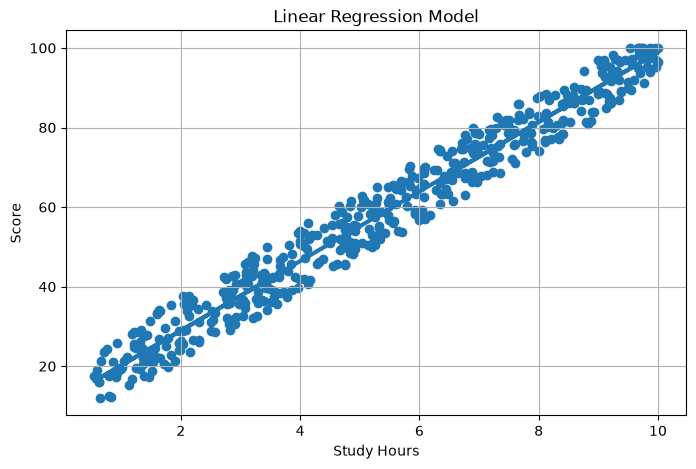

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(X, y)

plt.plot(X, model.predict(X), linewidth=3)

plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.title("Linear Regression Model")

plt.grid(True)

plt.show()

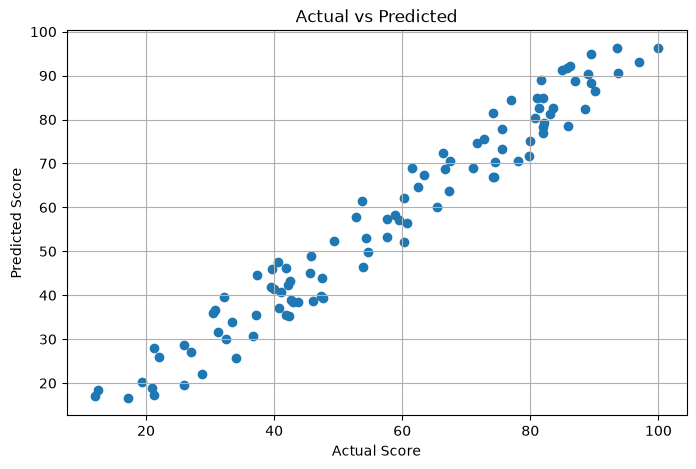

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

In [28]:
# Testing Model
hours = [[5]]

prediction = model.predict(hours)

print("Predicted Score :", prediction[0])

Predicted Score : 55.17713852378886


c:\Users\aryan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [29]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']

In [34]:
import pandas as pd

while True:
    hours = float(input("Enter study hours: "))

    # Create a DataFrame with the same column name used during training
    input_data = pd.DataFrame({
        "Study_Hours": [hours]
    })

    # Predict score
    prediction = model.predict(input_data)[0]

    # Keep prediction between 0 and 100
    prediction = max(0, min(100, prediction))

    print(f"Predicted Score: {prediction:.2f}")

    choice = input("Do you want to predict again? (yes/no): ").lower()

    if choice != "yes":
        print("Thank you!")
        break

Predicted Score: 28.94
Predicted Score: 55.18
Predicted Score: 81.42
Predicted Score: 90.16
Predicted Score: 100.00
Thank you!
